<a href="https://colab.research.google.com/github/daonkim462/FinanceSeminar/blob/main/Finance_seminar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 금융 세미나 With Python!!

## 금융 데이터와 컴퓨팅

###컴퓨터가 없던 시절의 금융 데이터
#### 먼 과거: 장부와 책을 뒤져가며 찾아가야 했던 금융 데이터
#### 1960년대: 금융 데이터의 디지털화 (시카고대의 CSRP, Compustat 등)
#### 1970년대:
* 세계 최초 전자거래시장 NASDAQ 출범, 전자 네트워크의 형성과 확산
* 컴퓨터의 연산 능력을 활용한 금융 공학의 발전
* 에드워드 소프의 세계 최초의 퀀트 펀드 PNP 설립
#### 1980년대:
* 블룸버그 터미널의 발명, 데이터의 확산 속도 증가
* 르네상스 테크놀로지의 메달리온 펀드 출범 (1988~2018까지 연평균 66%의 수익률 기록)
#### 1990년대:
* PC 보급의 확산으로 인한 투자의 디지털화
* LTCM의 실패 - 경제학, 수학 박사와 교수들, 그리고 심지어 노벨상 수상자까지 포함된 천재들의 실패
#### 2000년대 이후:
* 투자의 완전한 디지털화
* 여러 퀀트, 증권사, 자산운용사들의 컴퓨터를 활용한 투자경쟁
* 대체 데이터와 머신러닝의 활용
* 가상화폐의 등장

##금융 데이터, 어디에 쓰이고 어떤 것들이 있을까?

###데이터 전처리 및 활용
데이터를 수집, 가공하여 필요한 형태로 저장, 판매 혹은 이용
* 블룸버그, 퀀틀 등의 데이터 벤더에서 데이터를 대규모로 판매
* 다양한 스크리너 서비스에 활용
* 가격 데이터를 저장해 분/시/일 단위로 시각화
* 증권사나 자산운용사의 리서치팀에서의 데이터 수집
* 기관, 개인 투자자들도 이러한 데이터를 활용 가능
###투자 판단을 위한 데이터 분석에 사용
투자 전략을 수립하며 해당 전략을 검증, 보완하기 위한 도구로 활용
* 자산운용사의 DCF 계산
* 퀀트 리서처의 투자 가설 검증 및 분석
* 수정된 블랙 숄즈 공식을 활용해 옵션 가치 평가
###컴퓨터와 데이터로 실제 투자에 적용
컴퓨터를 이용한 자동화된 트레이딩
* 르네상스 테크놀로지, 시타델 등의 퀀트 기관에서의 적용
* 개인의 트레이딩 봇
* HFT를 통한 차익거래, 통계적 차익거래, 기업 가치평가 자동화 및 트레이딩 등 확률과 수학을 활용한 여러 투자 방법들

###금융 데이터의 종류
####정형 데이터
명확히 정해진 구조로 이루어진 데이터
* DB 내의 테이블
* CSV 파일
* 복식부기장

####비정형 데이터
정해진 형식과 구조 없이 저장된 데이터
* 뉴스
* 공시 원본 파일
* 여러 이미지, 동영상

####반정형 데이터
구조는 있지만 고정된 스키마가 없이 좀 더 유연하게 변형 가능한 데이터
* JSON
* HTML
* XBRL 공시 데이터

####데이터를 얻는 다양한 방법들
* 유료, 무료 API 이용
* 웹 크롤링, 스크래핑
* 직접 데이터를 생성 및 가공

##파이썬으로 공시 데이터 다루기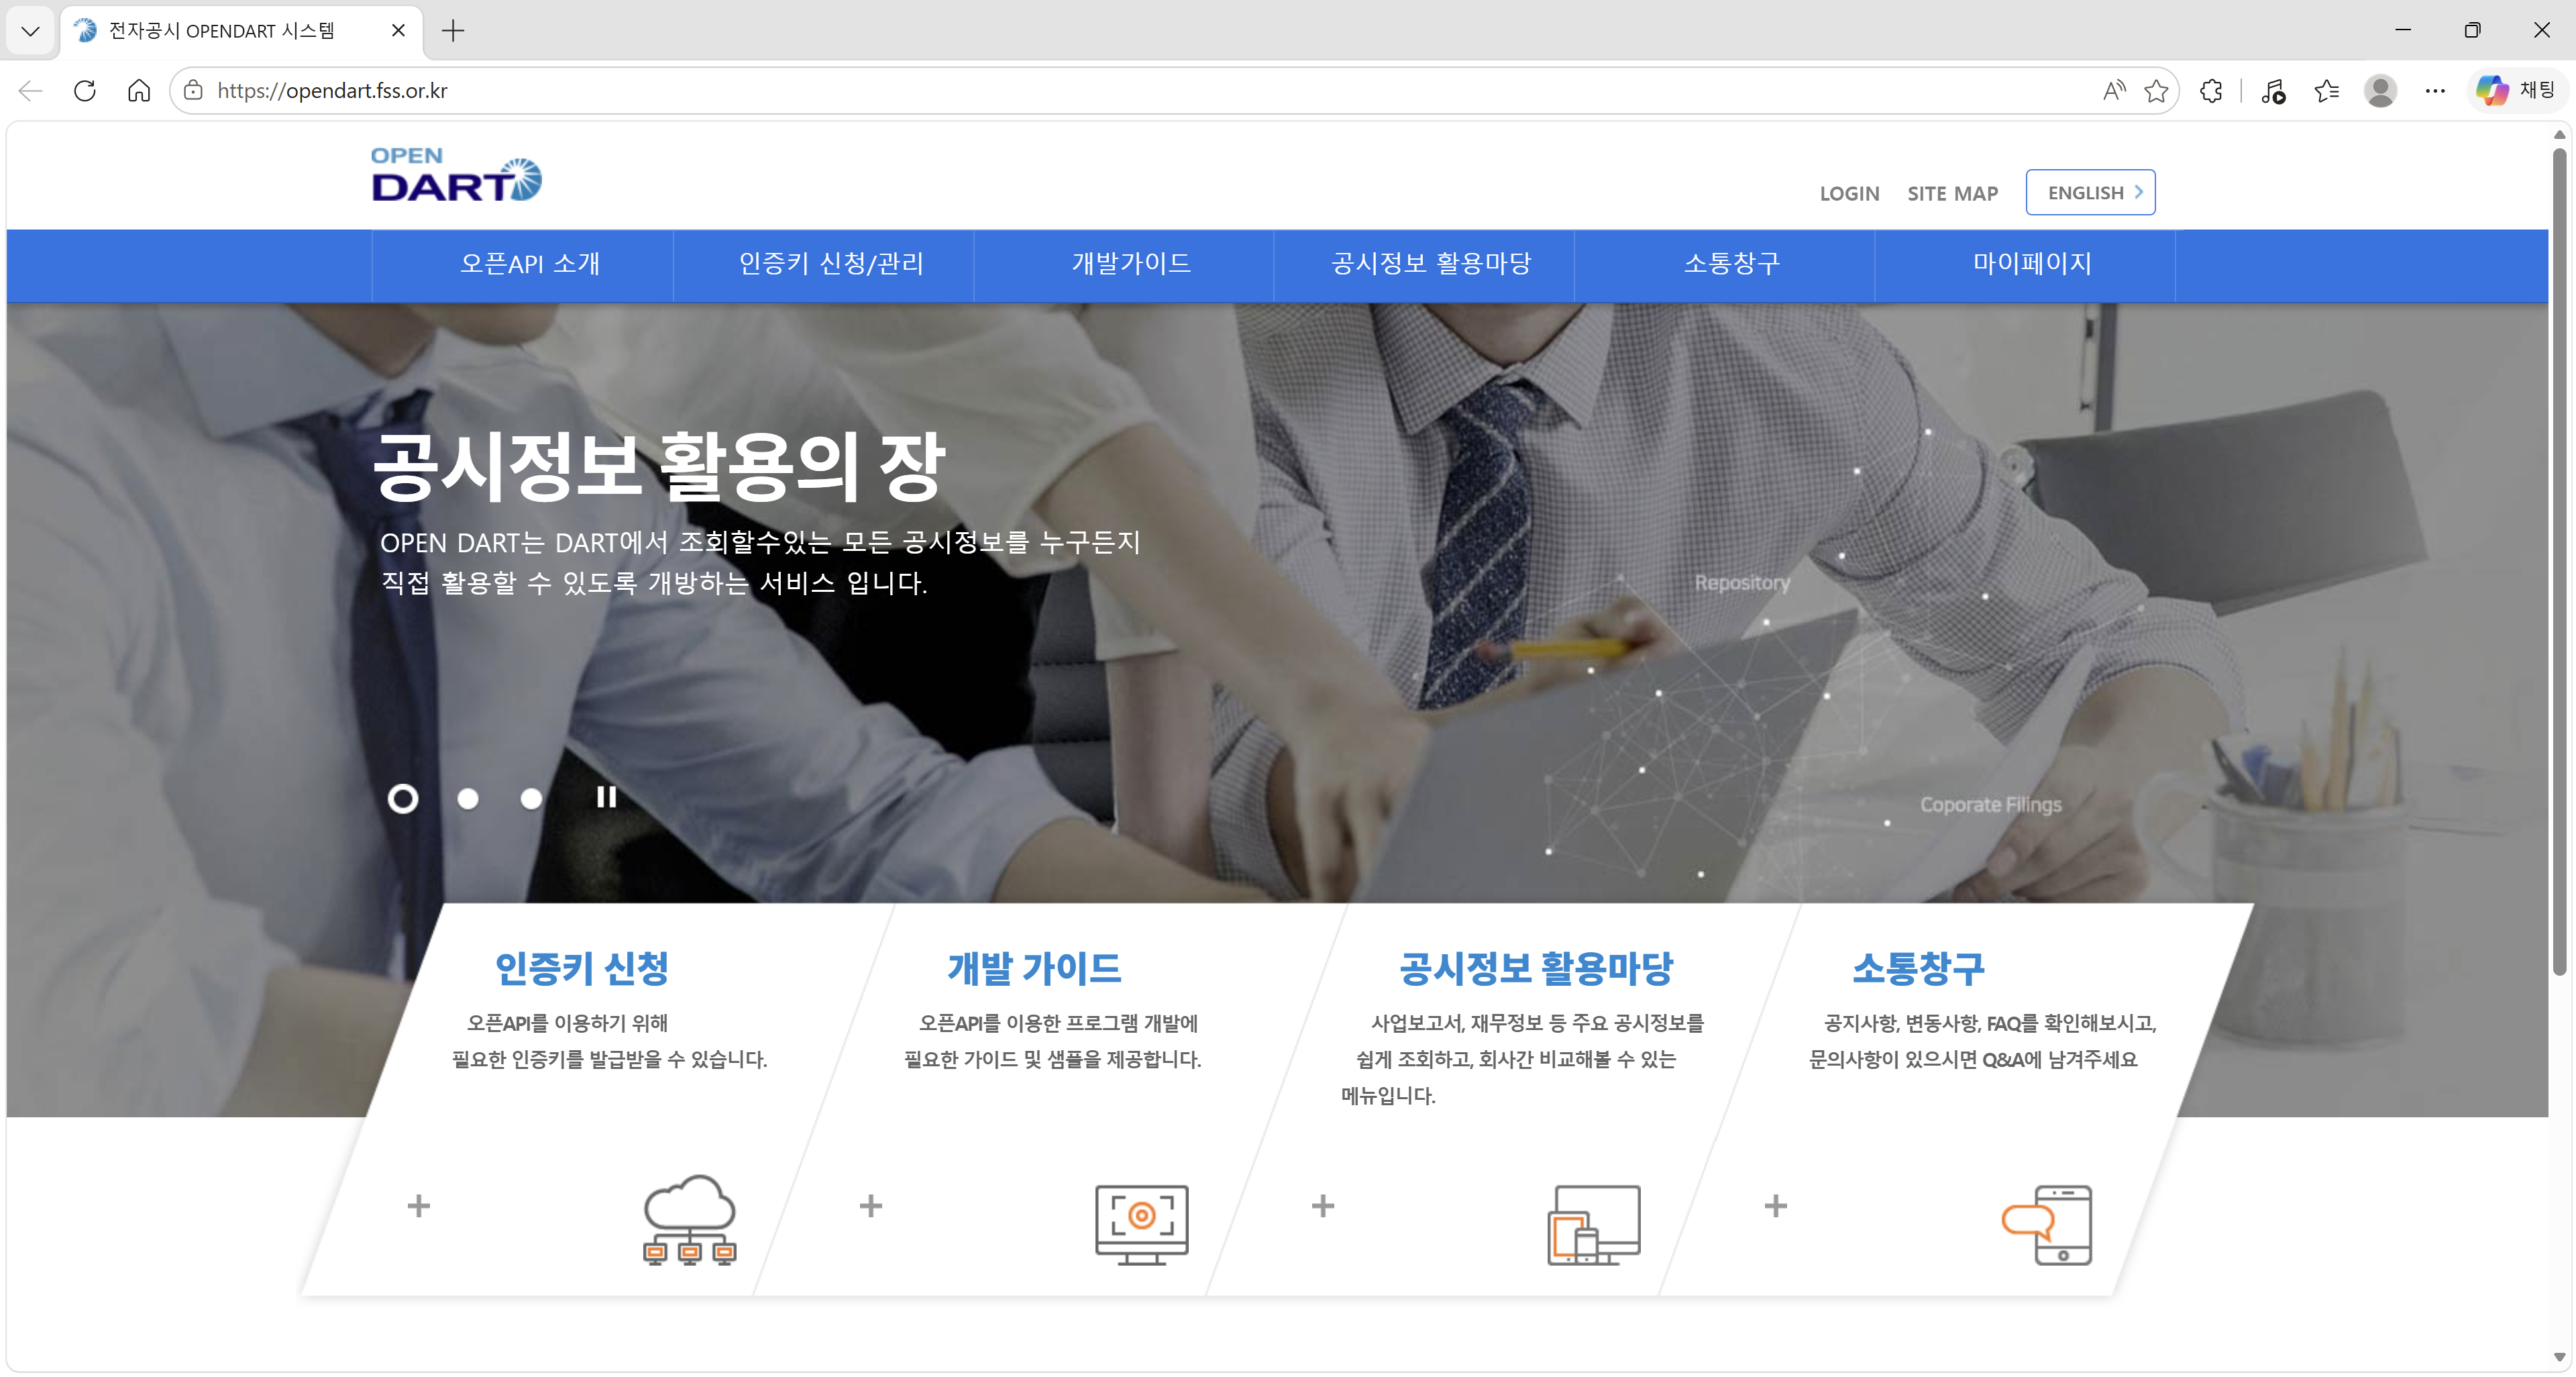

In [1]:
from zipfile import ZipFile
from pathlib import Path

zip_path = Path.cwd() / "20260310002820_ifrs.zip"

with ZipFile(zip_path, "r") as z:
    file_list = z.namelist()

file_list[:20]

['entity00126380_2025-12-31.xbrl',
 'entity00126380_2025-12-31.xsd',
 'entity00126380_2025-12-31_def.xml',
 'entity00126380_2025-12-31_cal.xml',
 'entity00126380_2025-12-31_pre.xml',
 'entity00126380_2025-12-31_lab-ko.xml',
 'entity00126380_2025-12-31_lab-en.xml']

####XBRL이란?
' 복잡한 기업정보를 효율적으로 생성/교환/비교할 수 있도록 만든 기업보고용 국제 표준화 언어 '

그렇지만 우선은 정리된 데이터를 다루도록 하자..

OPENDART 대표 재무정보 이미지

In [4]:
import requests
import json
import os

API_KEY = "본인_API_KEY"

url = "https://opendart.fss.or.kr/api/fnlttSinglAcnt.json"

params = {
    "crtfc_key": API_KEY,
    "corp_code": "00126380",
    "bsns_year": "2024",
    "reprt_code": "11011"
}

response = requests.get(url, params=params)
data = response.json()

save_path = os.path.join(os.getcwd(), "data.json")

with open(save_path, "w", encoding="utf-8") as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print(f"saved to {save_path}")




saved to C:\Users\Hom01\source\repos\FinanceSeminar\data.json
